## EXP-4 : NAIVE BAYES CLASSIFIER ##

### EXPERIMENT 3

In [ ]:
#Aryan Naikwadi
#24070127028

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler , Binarizer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import Gaussia nNB, MultinomialNB,BernoulliNB

from sklearn.metrics import (
    accuracy_score,confusion_matrix,classification_report,
    roc_curve,auc
)

import scipy.stats as stats

In [12]:
data = load_breast_cancer()
x=data.data
y=data.target

print("Dataset Shape:", x.shape)

Dataset Shape: (569, 30)


In [13]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [15]:
x_train ,x_test , y_train , y_test = train_test_split(
    x ,y, test_size=0.2 , random_state=42
)


In [17]:
# for gaussian NB --> Standard scaling
scaler_std = StandardScaler()
x_train_std=scaler_std.fit_transform(x_train)
x_test_std = scaler_std.transform(x_test)

 # for multinomial
scaler_mm = MinMaxScaler()
x_train_mm= scaler_mm.fit_transform(x_train)
x_test_mm = scaler_mm.transform(x_test)

#for bernaulli NB --> Binary feature 
binarizer = Binarizer(threshold=0.0)
x_train_bin =binarizer.fit_transform(x_train_mm)
x_test_bin =binarizer.transform(x_test_mm)

In [18]:
# gaussian NB
gnb = GaussianNB()
gnb.fit(x_train_std,y_train)
y_pred_gnb =gnb.predict(x_test_std)
y_prob_gnb= gnb.predict_proba(x_test_std)[:,1]

# multinomial NB
mnb= MultinomialNB()
mnb.fit(x_train_mm,y_train)
y_pred_mnb= mnb.predict(x_test_mm)
y_prob_mnb=mnb.predict_proba(x_test_mm)[:,1]

# Bernaulli NB
bnb = BernoulliNB()
bnb.fit(x_train_bin,y_train)
y_pred_bnb=bnb.predict(x_test_bin)
y_prob_bnb =bnb.predict_proba(x_test_bin)[:,1]

In [19]:
param_grid ={
    'var_smoothing': np.logspace(-12,-6,50)
}
gnb_grid = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring = 'accuracy',
    n_jobs=-1
)
gnb_grid.fit(x_train_std,y_train)

print("best params:",gnb_grid.best_params_)

gnb_best = gnb_grid.best_estimator_
y_pred_gnb_best = gnb_best.predict(x_test_std)


best params: {'var_smoothing': np.float64(1e-12)}


In [20]:
def evaluate_model(y_test, y_pred , y_prob , model_name):
    print(f"\n===={model_name}====")
    print("Accuracy:", accuracy_score(y_test,y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred))
    print("\nClassificatio Report:\n", classification_report(y_test,y_pred))

    fpr,tpr,_ = roc_curve(y_test,y_prob)
    roc_auc =auc(fpr,tpr)

    plt.figure()
    plt.plot(fpr,tpr,label="AUC =%.2f" % roc_auc)
    plt.plot([0,1],[0,1])
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{model_name} ROC Curve")
    plt.legend()
    plt.show()




====Gaussian NB====
Accuracy: 0.9649122807017544

Confusion Matrix:
 [[40  3]
 [ 1 70]]

Classificatio Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



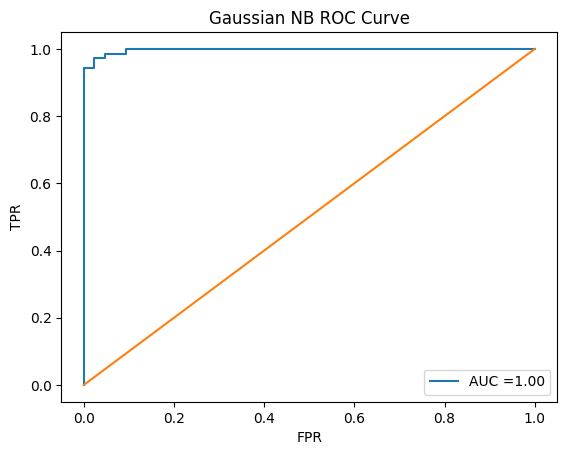


====Multinomial NB====
Accuracy: 0.8508771929824561

Confusion Matrix:
 [[26 17]
 [ 0 71]]

Classificatio Report:
               precision    recall  f1-score   support

           0       1.00      0.60      0.75        43
           1       0.81      1.00      0.89        71

    accuracy                           0.85       114
   macro avg       0.90      0.80      0.82       114
weighted avg       0.88      0.85      0.84       114



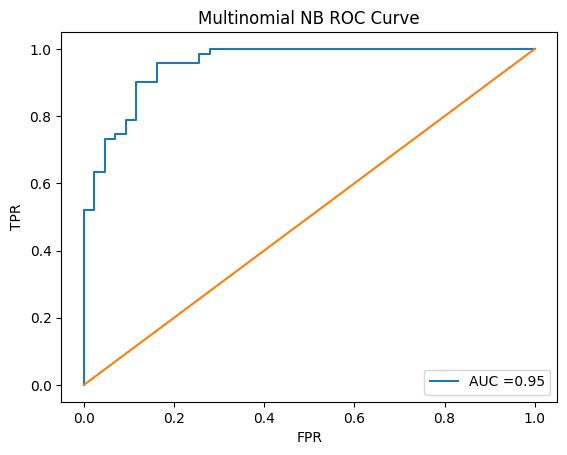


====Bernoulli NB====
Accuracy: 0.6228070175438597

Confusion Matrix:
 [[ 0 43]
 [ 0 71]]

Classificatio Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.62      1.00      0.77        71

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



C:\Users\Meenu rs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Meenu rs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Meenu rs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metr

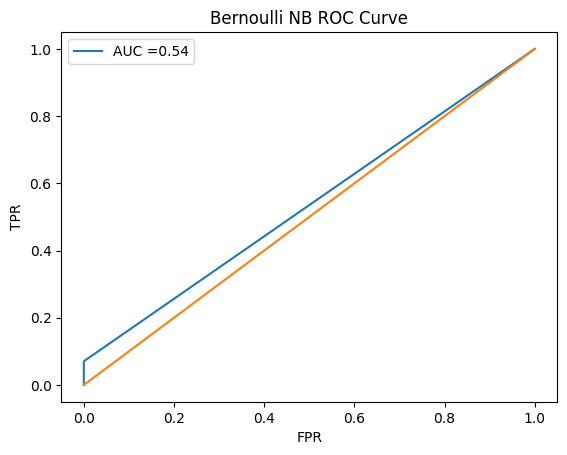


====Tuned Gaussian NB====
Accuracy: 0.9649122807017544

Confusion Matrix:
 [[40  3]
 [ 1 70]]

Classificatio Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



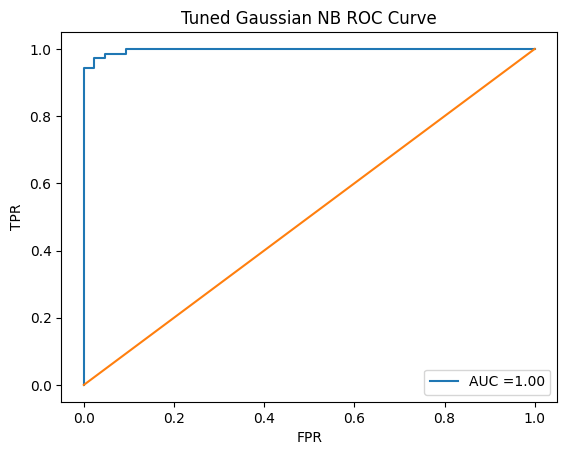

In [21]:
evaluate_model(y_test,y_pred_gnb, y_prob_gnb , "Gaussian NB")
evaluate_model(y_test,y_pred_mnb, y_prob_mnb , "Multinomial NB")
evaluate_model(y_test,y_pred_bnb, y_prob_bnb , "Bernoulli NB")
evaluate_model(y_test,y_pred_gnb_best, y_prob_gnb , "Tuned Gaussian NB")

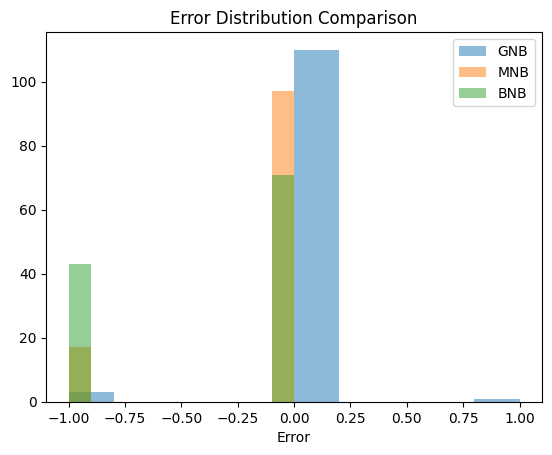

In [23]:
errors = {
    "GNB": y_test - y_pred_gnb,
    "MNB": y_test - y_pred_mnb,
    "BNB": y_test - y_pred_bnb
}

plt.figure()

for key,val in errors.items():
    plt.hist(val, alpha = 0.5, label=key)

plt.legend()
plt.title("Error Distribution Comparison")
plt.xlabel("Error")
plt.show()

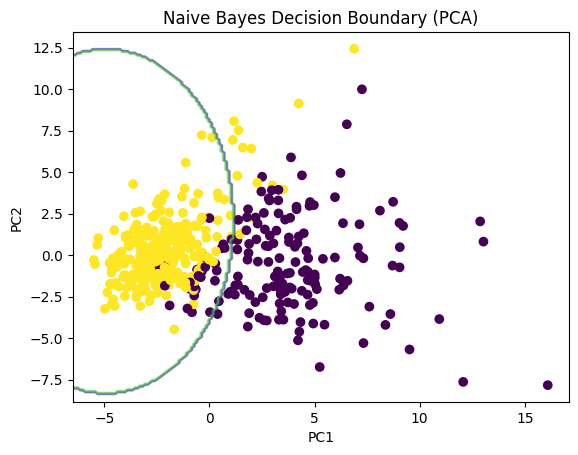

In [26]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(x_train_std)

gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca,y_train)

x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = gnb_pca.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contour(xx,yy,Z, alpha=0.3)

plt.scatter(X_train_pca[:,0],X_train_pca[:,1], c=y_train)

plt.title("Naive Bayes Decision Boundary (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()